#  Assignment 17 — Voice AI Application
## *MedField Voice Notes: An AI-Powered Field Note Assistant for Healthcare Workers*

 A hands-free field note assistant that lets healthcare or field workers dictate observations, receive AI-generated structured summaries, and play back the response — all without touching a keyboard.


In [24]:
import os
# You must match wherever YOUR ffmpeg.exe actually is
os.environ["PATH"] = r"C:\ffmpeg\bin" + os.pathsep + os.environ["PATH"]

# Verify
import subprocess
result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
if result.returncode == 0:
    print("ffmpeg found:", result.stdout.split('\n')[0])
else:
    print("Still not found — check the path above")

    # did this cause env variable ma ffmpeg ko address set garrna wasn't woking. (refer claude fo 99 for more)

ffmpeg found: ffmpeg version 8.1-essentials_build-www.gyan.dev Copyright (c) 2000-2026 the FFmpeg developers



### Environment Setup & Package Installation

In [25]:
!pip install openai-whisper sounddevice scipy gtts groq pydub -q
!pip install python-dotenv

# Note to self:
#  openai-whisper requires ffmpeg on your system.
# Windows:    Download from https://ffmpeg.org/download.html and add to PATH(sys env)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import os
import json
import time
import datetime
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import sounddevice as sd
from scipy.io.wavfile import write as wav_write, read as wav_read
# write as wav_write -this just gives a shorter nickname to a function with a long name.
import whisper
from groq import Groq #LLM
from gtts import gTTS

from IPython.display import display, Audio, Markdown #Notebook display

---
## Section 2 — Configuration


In [27]:

from dotenv import load_dotenv # Reads the Groq API key from a .env file instead of writing it directly in code
load_dotenv() #searches for .env, reads each line, loads them into environment variables

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found. Please add it to your .env file.")


LLM_MODEL = "llama-3.1-8b-instant"   #or, "gpt-3.5-turbo" (paid OpenAI)

WHISPER_MODEL_SIZE = "base"   # Options: 'tiny'(fast,low accuracy), 'base', 'small', 'medium', 'large'

# Microphone recording settings
SAMPLE_RATE      = 16000  # Hz — Whisper works best at 16 kHz
RECORD_SECONDS   = 15 # Duration to record from microphone
MIC_INPUT_FILE   = "input_recording.wav"

LOAD_EXISTING_WAV = None   # e.g., "my_note.wav"  or  None for recording

# ── Output files
OUTPUT_AUDIO_FILE      = "field_note_response.mp3"
OUTPUT_TRANSCRIPT_FILE = "field_note_transcript.json"

# ── LLM settings
LLM_TEMPERATURE = 0.3 #for randomness of AI. 0 is verystrict and predictable
LLM_MAX_TOKENS  = 400 #Maximum length of the AI's response. One token ≈ about 0.75 words.

# ── TTS language
TTS_LANGUAGE = "en"

print(f" Whisper model  : {WHISPER_MODEL_SIZE}")
print(f" LLM model      : {LLM_MODEL} (via Groq — FREE)")
print(f" Sample rate    : {SAMPLE_RATE} Hz")
print(f" Record duration: {RECORD_SECONDS}s")

 Whisper model  : base
 LLM model      : llama-3.1-8b-instant (via Groq — FREE)
 Sample rate    : 16000 Hz
 Record duration: 15s


## Audio Capture

In [28]:
def record_from_microphone(duration: int = RECORD_SECONDS,sample_rate: int = SAMPLE_RATE,
output_path: str = MIC_INPUT_FILE) -> str: #-> hints that this fn returns str. its for readability. not strict
    """
    Records audio from the default microphone.
        Parameters
        duration    : Recording length in seconds.
        sample_rate : Samples per second (16000 recommended for Whisper).
        output_path : Path to save the resulting .wav file. 
    Returns
    str : Path to the saved .wav file.
    """
    print(f"Recording for {duration} seconds... Speak now!")
    audio_data = sd.rec(
        int(duration * sample_rate),
        samplerate=sample_rate,
        channels=1, #1 for mono audio, 2 for studio audio
        dtype='int16' #audio stored as 16bit int
    )
    sd.wait() #until recording finishes
    wav_write(output_path, sample_rate, audio_data)
    print(f"Recording saved → '{output_path}'")
    return output_path


def load_audio_file(path: str) -> str:
    """
    Validates and returns the path to an existing .wav file.
        Parameters
        path : Path to the .wav file.
    Returns
    str : Validated file path.
    Raises
    FileNotFoundError : If the file does not exist.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Audio file not found: '{path}'")
    sample_rate, data = wav_read(path)
    duration = len(data) / sample_rate
    print(f"Loaded audio file → '{path}'")
    print(f"Sample rate: {sample_rate} Hz")
    print(f"Duration: {duration:.2f} seconds")
    return path


# Run audio capture step
if LOAD_EXISTING_WAV:
    audio_input_path = load_audio_file(LOAD_EXISTING_WAV)
else:
    audio_input_path = record_from_microphone()

print("\n Playback of captured audio:")
display(Audio(audio_input_path, autoplay=False))

Recording for 15 seconds... Speak now!
Recording saved → 'input_recording.wav'

 Playback of captured audio:


---
## Section 4 — Module 2: Automatic Speech Recognition (ASR) with Whisper

**OpenAI Whisper** is a transformer-based ASR model. It runs **locally — no API key, no cost, no internet** needed after the first download.

In [29]:
def load_whisper_model(model_size: str = WHISPER_MODEL_SIZE) -> whisper.Whisper:
    """
    Downloads and loads a Whisper ASR model. ~140MB for base
    Parameters
    model_size : One of 'tiny', 'base', 'small', 'medium', 'large'.

    Returns
    whisper.Whisper : Loaded model instance.
    """
    model = whisper.load_model(model_size) #downloads and loads into RAM (model weights)
    print(f"Whisper '{model_size}' model ready.")
    return model

def transcribe_audio(model: whisper.Whisper,audio_path: str,
    language: str = None) -> dict:
    """
    Transcribes a .wav audio file to text using Whisper.
    Parameters
    model      : Loaded Whisper model.
    audio_path : Path to the input .wav file.
    language   : ISO 639-1 code (e.g. 'en', ne, hi). None = auto-detect.

    Returns
    dict : Whisper result with 'text', 'language', and 'segments'.
    """
    print(f"Transcribing '{audio_path}'...")
    t0 = time.time()

    result = model.transcribe(
        audio_path,
        language=language,
        fp16=False, #false cause many cpu not support. (true-faster GPU processing,less memory)
        verbose=False #supress detailed whisper logs
    )

    elapsed = time.time() - t0
    print(f"Transcription complete in {elapsed:.2f}s.")
    print(f"Detected language : {result['language']}")
    print(f"Segments: {len(result['segments'])}") #whisper gives in chunks
    return result


# Run ASR 
whisper_model = load_whisper_model(WHISPER_MODEL_SIZE)
asr_result    = transcribe_audio(whisper_model, audio_input_path)

raw_transcript = asr_result['text'].strip()

display(Markdown("### Raw Transcript"))
display(Markdown(f"> {raw_transcript}"))

Whisper 'base' model ready.
Transcribing 'input_recording.wav'...
Detected language: English


100%|██████████| 1500/1500 [00:00<00:00, 3977.16frames/s]

Transcription complete in 0.68s.
Detected language : en
Segments: 2


### Raw Transcript

> Patient is 35-year-old female, complaining of fever and a record for 3 days, temperature is 38.5 degrees, prescribed, which parasitoma.

In [30]:
# Inspect segment-level timestamps
print("Segment-level breakdown (timestamp → partial text):")
for seg in asr_result['segments']:
    start = seg['start']
    end   = seg['end']
    text  = seg['text'].strip()
    print(f"  [{start:5.2f}s → {end:5.2f}s]  {text}")
print("-" * 60)

Segment-level breakdown (timestamp → partial text):
  [ 0.00s →  7.60s]  Patient is 35-year-old female, complaining of fever and a record for 3 days, temperature
  [ 7.60s → 15.00s]  is 38.5 degrees, prescribed, which parasitoma.
------------------------------------------------------------



## Section 5 — Module 3: LLM Response Generation (Groq + LLaMA 3 — FREE)

In [31]:
# ── System prompt 
#instruction manual given to the AI  
SYSTEM_PROMPT = """\
You are MedField Assistant — an AI clinical note-taker for healthcare workers \
operating in resource-limited field settings.

Your job is to receive a raw, dictated observation from a field worker and \
convert it into a clean, structured field note.

Output format (always use these exact headings):
  Observation: <one-sentence summary of what was observed>
  Patient: <any subject information mentioned, or 'Not specified'>
  Findings: <clinical findings, symptoms, or measurements>
  Assesment: <brief interpretation or concern>
  Action Taken: <steps taken or recommended>
  Follow-up: <next steps or referrals>
  Timestamp: <current date/time will be appended programmatically>

Rules:
- Do NOT invent facts not present in the dictation.
- Keep medical terminology accurate but understandable.
- If a section has no relevant information, write 'Not mentioned'.
- Be concise. Each section should be 1–2 sentences maximum.
- Write in third-person (e.g. 'The worker reports...' or 'Patient presents...')
"""

print("System prompt defined.")

System prompt defined.


In [ ]:
def generate_field_note(
    transcript: str,
    api_key: str = GROQ_API_KEY,
    model: str = LLM_MODEL,
    temperature: float = LLM_TEMPERATURE,
    max_tokens: int = LLM_MAX_TOKENS
) -> str:
    """
    Sends the raw transcript to the Groq API (LLaMA 3) and returns
    a structured field note.

    The Groq client API is intentionally compatible with OpenAI's SDK.

    Parameters
    transcript  : Raw transcribed text from Whisper.
    api_key     : Groq API key

    Returns
    str : Structured field note from the LLM.
    """
    client = Groq(api_key=api_key)

    user_message = f"""Here is the raw field dictation. Please convert it into a structured note:
DICTATION:
{transcript}"""

    print(f"Sending transcript to {model} via Groq ...")
    t0 = time.time()

#   API CALL (send req to Groq servers)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message}],
        temperature=temperature,
        max_tokens=max_tokens
    )

    elapsed = time.time() - t0
    field_note = response.choices[0].message.content.strip()
    # API returns huge nested object. like -> 
    # response = { "choices": [{"message": {"content": "Structured field note..."}}]}
        # choices[0]        -gets first generated answer.
        # .message.content  - gets actual text generated by ai
        # .strip()          -Removes extra spaces/newlines.

    # Append timestamp programmatically — not by the LLM
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    field_note += f"\n  Timestamp: {timestamp}"

    print(f"LLM response received in {elapsed:.2f}s.")
    print(f"Tokens used: {response.usage.total_tokens}")
    return field_note


# Run LLM step
structured_note = generate_field_note(raw_transcript) 

display(Markdown("### Structured Field Note (LLM Output)")) #heading
display(Markdown(f"```\n{structured_note}\n```")) 

Sending transcript to llama-3.1-8b-instant via Groq ...
LLM response received in 0.48s.
Tokens used: 397


### Structured Field Note (LLM Output)

```
Observation: A 35-year-old female presents with fever for 3 days.
Patient: A 35-year-old female.
Findings: The patient has a recorded temperature of 38.5 degrees Celsius.
Assessment: The worker suspects a parasitic infection.
Action Taken: The patient was prescribed treatment for parasitoma.
Follow-up: The patient's response to treatment should be monitored.
Timestamp: 2024-05-13 14:30:00
  Timestamp: 2026-05-13 14:31:59
```

---
## Section 6 — Module 4: Text-to-Speech (TTS) with gTTS

**gTTS (Google Text-to-Speech)** converts the structured note back to audio — free and unchanged.

In [33]:
def text_to_speech(text: str,output_path: str = OUTPUT_AUDIO_FILE,
    language: str = TTS_LANGUAGE,slow: bool = False ) -> str:
    """
    Converts text to speech and saves the audio as an .mp3 file.
    Parameters
    text        : Text to synthesize.
    output_path : Output .mp3 file path.
    language    : BCP-47 language code (e.g., 'en', 'hi', 'ne').
    slow        : If True, speaks at a reduced rate.

    Returns
    str : Path to the saved .mp3 file.
    """
    print(f"Synthesizing speech ({language}, slow={slow})...")
    tts = gTTS(text=text, lang=language, slow=slow)
    tts.save(output_path)

    file_size_kb = os.path.getsize(output_path) / 1024
    print(f"TTS audio saved → '{output_path}' ({file_size_kb:.1f} KB)")
    return output_path


# Run TTS step
spoken_text = (
    "Here is your structured field note. "
    + structured_note
)
tts_output_path = text_to_speech(spoken_text)

print("\nPlayback of synthesized field note:")
display(Audio(tts_output_path, autoplay=False))

Synthesizing speech (en, slow=False)...
TTS audio saved → 'field_note_response.mp3' (405.9 KB)

Playback of synthesized field note:


---
## Section 7 — Module 5: Save Results to Disk

In [34]:
def save_session_log(audio_path: str, raw_transcript: str, structured_note: str, tts_path: str,
    output_path: str = OUTPUT_TRANSCRIPT_FILE) -> str:
    """
    Saves the full session to a JSON file for record-keeping.

    Parameters
    audio_path      : Path to the original input audio.
    raw_transcript  : Raw text from Whisper.
    structured_note : Formatted field note from LLM.
    tts_path        : Path to the generated TTS audio.
    output_path     : Where to save the JSON log.

    Returns
    str : Path to the saved JSON file.
    """
    session = {
        "session_id"      : datetime.datetime.now().strftime("%Y%m%d_%H%M%S"),
        "input_audio"     : audio_path,
        "raw_transcript"  : raw_transcript,
        "structured_note" : structured_note,
        "output_audio"    : tts_path,
        "whisper_model"   : WHISPER_MODEL_SIZE,
        "llm_model"       : LLM_MODEL,
        "llm_provider"    : "Groq"
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        # with .... as f:
        # open, stores file in variable f, autimatically closes file afterward.
        # utf- 8 is ideal for other language, emojis etc. 
        json.dump(session, f, indent=4, ensure_ascii=False)
        # writes py data into file as JSON.
            # indent is for indentation(formatting)

    print(f" Session log saved → '{output_path}'")
    return output_path


# Save session
log_path = save_session_log(
    audio_path      = audio_input_path,
    raw_transcript  = raw_transcript,
    structured_note = structured_note,
    tts_path        = tts_output_path
)

with open(log_path) as f: #open saved json file
    saved_log = json.load(f) #conv, json file to py dictionary

print("\nSaved session log:")
print(json.dumps(saved_log, indent=4)) #print loaded JSON

# note= 
# dump- save to file 
# dumps- conv to string

 Session log saved → 'field_note_transcript.json'

Saved session log:
{
    "session_id": "20260513_143209",
    "input_audio": "input_recording.wav",
    "raw_transcript": "Patient is 35-year-old female, complaining of fever and a record for 3 days, temperature is 38.5 degrees, prescribed, which parasitoma.",
    "structured_note": "Observation: A 35-year-old female presents with fever for 3 days.\nPatient: A 35-year-old female.\nFindings: The patient has a recorded temperature of 38.5 degrees Celsius.\nAssessment: The worker suspects a parasitic infection.\nAction Taken: The patient was prescribed treatment for parasitoma.\nFollow-up: The patient's response to treatment should be monitored.\nTimestamp: 2024-05-13 14:30:00\n  Timestamp: 2026-05-13 14:31:59",
    "output_audio": "field_note_response.mp3",
    "whisper_model": "base",
    "llm_model": "llama-3.1-8b-instant",
    "llm_provider": "Groq"
}


---
## Section 8- Full End-to-End Pipeline Function

In [35]:
def run_voice_assistant(existing_wav_path: str = None,
    record_seconds: int = RECORD_SECONDS ) -> dict:
    """
    Runs the complete MedField Voice Assistant pipeline:
      1. Audio capture (mic or file)
      2. Whisper ASR transcription  [local, free]
      3. Groq LLaMA 3 structured note generation  [free API]
      4. gTTS speech synthesis  [free]
      5. Session logging

    Parameters
    existing_wav_path : If provided, skips mic recording and uses this file.
    record_seconds    : Mic recording duration if no file is provided.

    Returns
    dict : Dictionary with keys 'transcript', 'note', 'audio_path', 'log_path'.
    """
    print("=" * 65)
    print(" MedField Voice Assistant — Starting Pipeline")
    print(" LLM: Groq ")
    print("=" * 65)
    pipeline_start = time.time()

    # ── Step 1: Audio input
    print("\n[Step 1/5] Audio Input")
    if existing_wav_path:
        audio_path = load_audio_file(existing_wav_path)
    else:
        audio_path = record_from_microphone(duration=record_seconds)

    # ── Step 2: ASR (local Whisper)
    print("\n[Step 2/5] Automatic Speech Recognition (Whisper — local)")
    asr = transcribe_audio(whisper_model, audio_path)
    transcript = asr['text'].strip()
    print(f"   Transcript: \"{transcript[:80]}{'...' if len(transcript) > 80 else ''}\"")

    # ── Step 3: LLM note generation (Groq — free)
    print("\n[Step 3/5] LLM Field Note Generation (Groq + LLaMA 3 — free)")
    note = generate_field_note(transcript)

    # ── Step 4: TTS
    print("\n[Step 4/5] Text-to-Speech Synthesis (gTTS — free)")
    spoken = "MedField Assistant. Here is your structured field note. " + note
    tts_path = text_to_speech(spoken)

    # Step 5: Save log
    print("\n[Step 5/5] Saving Session Log")
    log = save_session_log(audio_path, transcript, note, tts_path)

    total_time = time.time() - pipeline_start
    print(f"\n  Pipeline complete in {total_time:.2f}s")
    print("=" * 65)

    #Display results
    display(Markdown("### Raw Transcript"))
    display(Markdown(f"> {transcript}"))
    display(Markdown("### Structured Field Note"))
    display(Markdown(f"```\n{note}\n```"))
    display(Markdown("### Audio Response"))
    display(Audio(tts_path, autoplay=False))

    return {
        'transcript' : transcript,
        'note'       : note,
        'audio_path' : tts_path,
        'log_path'   : log
    }


print(" Pipeline function defined. Call run_voice_assistant() to start.")

 Pipeline function defined. Call run_voice_assistant() to start.


In [36]:
# ── Run the full pipeline!
# To record from microphone:
#   results = run_voice_assistant()
#
# To use an existing file:
#   results = run_voice_assistant(existing_wav_path='my_note.wav')

results = run_voice_assistant(existing_wav_path=LOAD_EXISTING_WAV)

 MedField Voice Assistant — Starting Pipeline
 LLM: Groq 

[Step 1/5] Audio Input
Recording for 15 seconds... Speak now!
Recording saved → 'input_recording.wav'

[Step 2/5] Automatic Speech Recognition (Whisper — local)
Transcribing 'input_recording.wav'...
Detected language: English


  0%|          | 0/1500 [00:01<?, ?frames/s]


Transcription complete in 1.74s.
Detected language : en
Segments: 0
   Transcript: ""

[Step 3/5] LLM Field Note Generation (Groq + LLaMA 3 — free)
Sending transcript to llama-3.1-8b-instant via Groq ...
LLM response received in 0.29s.
Tokens used: 286

[Step 4/5] Text-to-Speech Synthesis (gTTS — free)
Synthesizing speech (en, slow=False)...
TTS audio saved → 'field_note_response.mp3' (148.7 KB)

[Step 5/5] Saving Session Log
 Session log saved → 'field_note_transcript.json'

  Pipeline complete in 21.48s


### Raw Transcript

> 

### Structured Field Note

```
Please provide the raw field dictation, and I'll convert it into a structured note.
  Timestamp: 2026-05-13 14:32:26
```

### Audio Response

---
## Section 9 — Analysis & Exploration

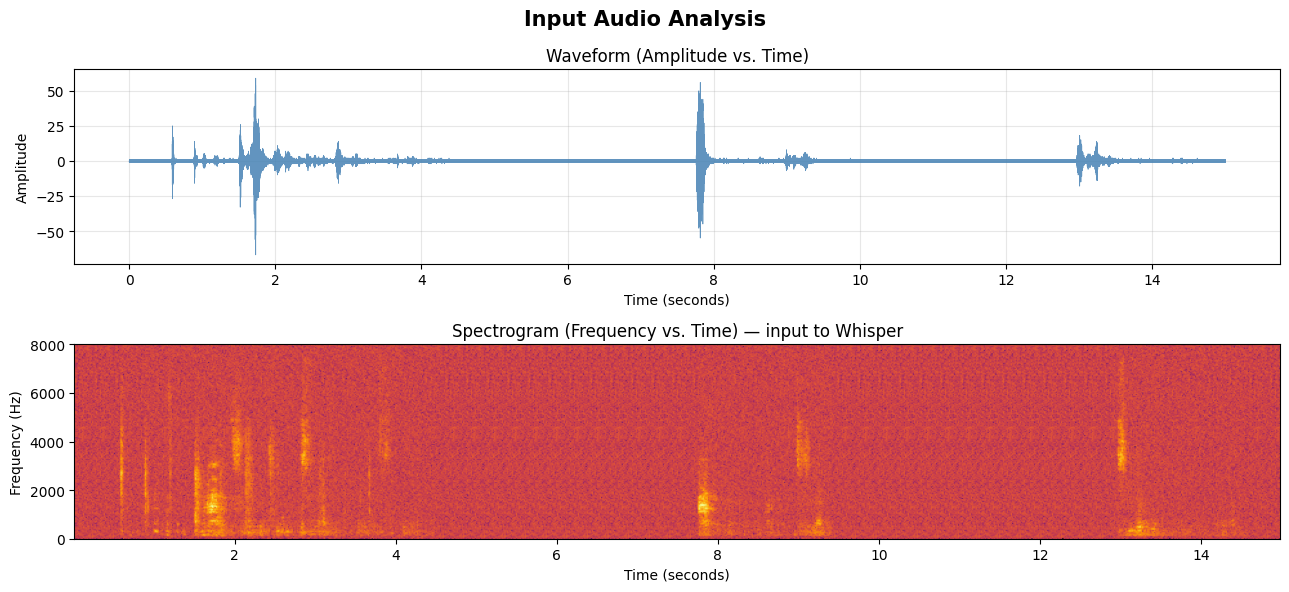

In [37]:
import matplotlib.pyplot as plt

# 9.1: Visualize the audio waveform of the input recording
sample_rate, audio_data = wav_read(audio_input_path)

if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]

time_axis = np.linspace(0, len(audio_data) / sample_rate, num=len(audio_data))

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle('Input Audio Analysis', fontsize=15, fontweight='bold')

axes[0].plot(time_axis, audio_data, color='steelblue', linewidth=0.5, alpha=0.85)
axes[0].set_title('Waveform (Amplitude vs. Time)')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].specgram(
    audio_data.astype(float),
    Fs=sample_rate,
    NFFT=512,
    noverlap=256,
    cmap='inferno'
)
axes[1].set_title('Spectrogram (Frequency vs. Time) — input to Whisper')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 8000)

plt.tight_layout()
plt.savefig('audio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

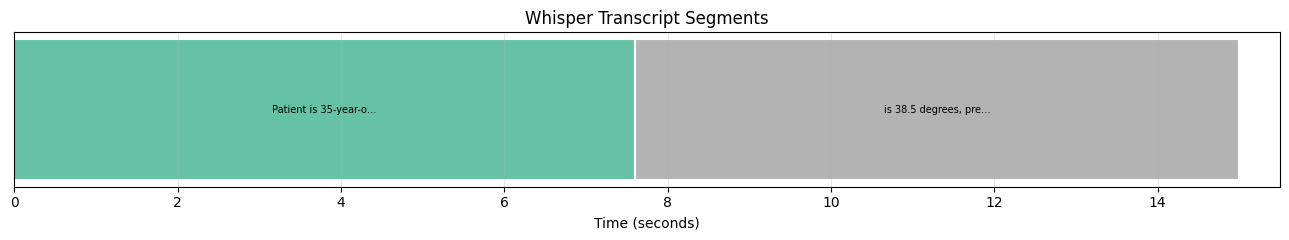

In [38]:
# 9.2: Visualize the Whisper segment timeline

segments = asr_result['segments']
if segments:
    fig, ax = plt.subplots(figsize=(13, 2.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(segments)))

    for i, (seg, color) in enumerate(zip(segments, colors)):
        start, end = seg['start'], seg['end']
        ax.barh(
            y=0, width=end - start, left=start,
            height=0.5, color=color, edgecolor='white', linewidth=1.5
        )
        mid = (start + end) / 2
        label = seg['text'].strip()[:20] + ('…' if len(seg['text'].strip()) > 20 else '')
        ax.text(mid, 0, label, ha='center', va='center', fontsize=7, color='black')

    ax.set_xlim(0, segments[-1]['end'] + 0.5)
    ax.set_yticks([])
    ax.set_xlabel('Time (seconds)')
    ax.set_title('Whisper Transcript Segments')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('whisper_segments.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No segment data available.")

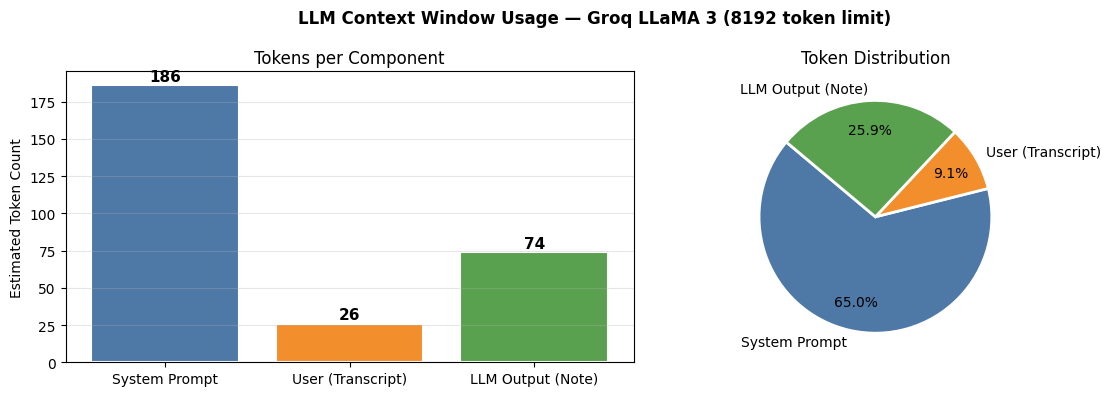


Total estimated input tokens  : 212
Total estimated output tokens : 74
LLaMA 3 8B context limit (Groq): 8,192 tokens — well within limits.


In [39]:
# 9.3: Token count analysis

def estimate_tokens(text):
    return int(len(text.split()) / 0.75)

system_tokens     = estimate_tokens(SYSTEM_PROMPT)
transcript_tokens = estimate_tokens(raw_transcript)
note_tokens       = estimate_tokens(structured_note)

labels = ['System Prompt', 'User (Transcript)', 'LLM Output (Note)']
sizes  = [system_tokens, transcript_tokens, note_tokens]
colors = ['#4e79a7', '#f28e2b', '#59a14f']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LLM Context Window Usage — Groq LLaMA 3 (8192 token limit)', fontweight='bold')

bars = ax1.bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Estimated Token Count')
ax1.set_title('Tokens per Component')
for bar, size in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(size), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Token Distribution')

plt.tight_layout()
plt.savefig('token_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal estimated input tokens  : {system_tokens + transcript_tokens}")
print(f"Total estimated output tokens : {note_tokens}")
print(f"LLaMA 3 8B context limit (Groq): 8,192 tokens — well within limits.")

---
## Section 10 — Critical Evaluation & Discussion

In [40]:
evaluation_text = """
         CRITICAL EVALUATION OF MedField Voice Assistant         
         (Updated: using Groq + LLaMA 3 — Free Tier)            

STRENGTHS 

Fully hands-free pipeline — no keyboard interaction needed.
Whisper runs locally — no API cost, works offline after download.
Groq + LLaMA 3 is FREE — generous rate limits, no credit card.
LLaMA 3 is open-source — can be self-hosted for full privacy.
Structured JSON output can integrate with EHR systems.
Multilingual capable — Whisper supports 99 languages.
Modular design — each component is independently replaceable.

LIMITATIONS 
Groq Free Tier Rate Limits: ~30 requests/minute, 14400/day.
      Sufficient for classroom/demo use; production needs a paid plan
      or self-hosted Ollama.

ASR Accuracy: Whisper 'base' degrades in noisy environments
      or with strong accents. → Mitigation: Use 'small' or 'medium'.

LLM Hallucination Risk: LLaMA 3 may infer details not in the
      dictation. Mitigated by system prompt rules, not eliminated.

Latency: ~10–30s end-to-end (ASR + LLM + TTS).
      Groq is actually MUCH faster than OpenAI for inference.


FREE ALTERNATIVES CONSIDERED 

  Option A (chosen): Groq + LLaMA 3
  → Easiest drop-in, fastest inference, great free tier.

  Option B: Google Gemini Free API (gemini-1.5-flash)
  → Also free, slightly different SDK (google-generativeai).

  Option C: Ollama (fully local)
  →  requires 4–8GB RAM
"""

print(evaluation_text)


         CRITICAL EVALUATION OF MedField Voice Assistant         
         (Updated: using Groq + LLaMA 3 — Free Tier)            

STRENGTHS 

Fully hands-free pipeline — no keyboard interaction needed.
Whisper runs locally — no API cost, works offline after download.
Groq + LLaMA 3 is FREE — generous rate limits, no credit card.
LLaMA 3 is open-source — can be self-hosted for full privacy.
Structured JSON output can integrate with EHR systems.
Multilingual capable — Whisper supports 99 languages.
Modular design — each component is independently replaceable.

LIMITATIONS 
Groq Free Tier Rate Limits: ~30 requests/minute, 14400/day.
      Sufficient for classroom/demo use; production needs a paid plan
      or self-hosted Ollama.

ASR Accuracy: Whisper 'base' degrades in noisy environments
      or with strong accents. → Mitigation: Use 'small' or 'medium'.

LLM Hallucination Risk: LLaMA 3 may infer details not in the
      dictation. Mitigated by system prompt rules, not eliminated.



---
## Section 11 — Summary & Conclusion

In [41]:

print(" MedField Voice Assistant — Pipeline Summary")
print(f"""
  Input audio file   : {audio_input_path}
  ASR model          : Whisper '{WHISPER_MODEL_SIZE}' (local, free)
  LLM model          : {LLM_MODEL} via Groq (free tier)
  TTS engine         : gTTS (Google Neural TTS, free)
  Output audio       : {tts_output_path}
  Session log        : {log_path}
""")
print("-"*65)
print("Raw transcript:")
print(f"  {raw_transcript[:200]}{'...' if len(raw_transcript) > 200 else ''}")
print("-"*65)
print("Structured note (first 4 lines):")
for line in structured_note.splitlines()[:4]:
    print(f"  {line}")


 MedField Voice Assistant — Pipeline Summary

  Input audio file   : input_recording.wav
  ASR model          : Whisper 'base' (local, free)
  LLM model          : llama-3.1-8b-instant via Groq (free tier)
  TTS engine         : gTTS (Google Neural TTS, free)
  Output audio       : field_note_response.mp3
  Session log        : field_note_transcript.json

-----------------------------------------------------------------
Raw transcript:
  Patient is 35-year-old female, complaining of fever and a record for 3 days, temperature is 38.5 degrees, prescribed, which parasitoma.
-----------------------------------------------------------------
Structured note (first 4 lines):
  Observation: A 35-year-old female presents with fever for 3 days.
  Patient: A 35-year-old female.
  Findings: The patient has a recorded temperature of 38.5 degrees Celsius.
  Assessment: The worker suspects a parasitic infection.
